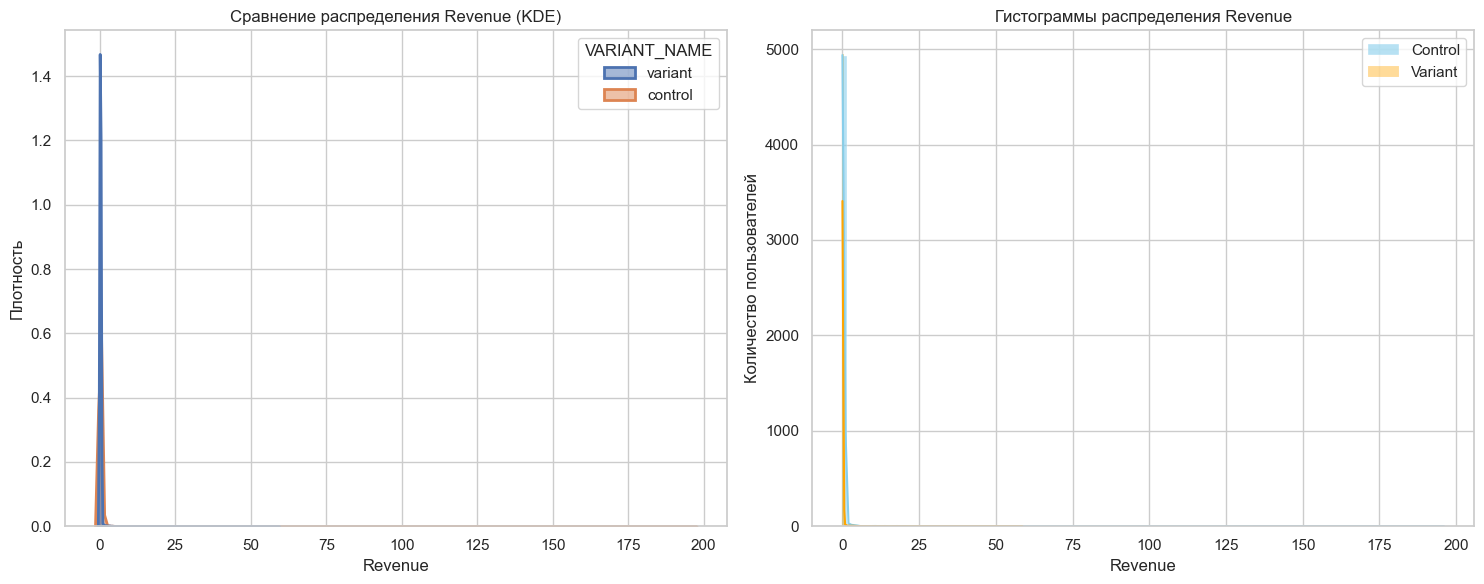

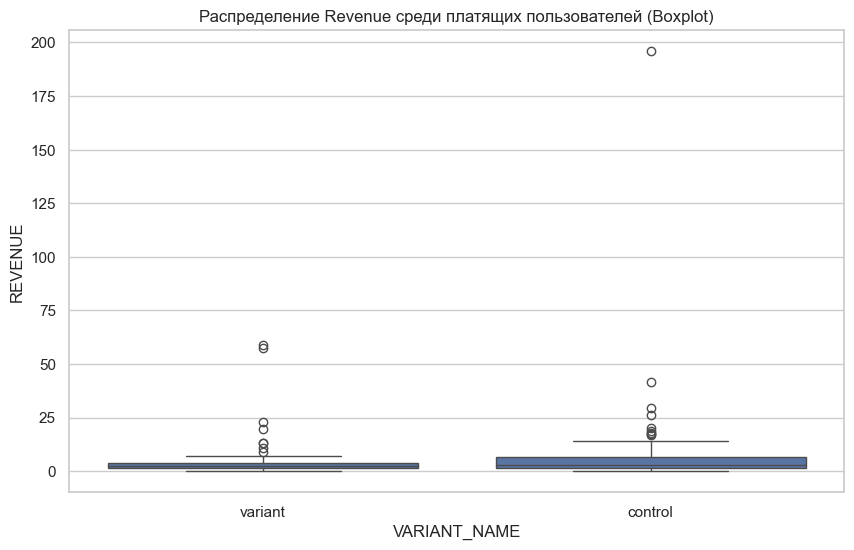

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('AB_Test_Results.csv')

# Инициализация стилей для аккуратного отображения
sns.set_theme(style="whitegrid")

# Разделение данных на две группы
control_revenue = df[df["VARIANT_NAME"] == "control"]["REVENUE"]
variant_revenue = df[df["VARIANT_NAME"] == "variant"]["REVENUE"]

# Создаем фигуру с двумя графиками: один общий (KDE), другие — раздельные гистограммы
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. График плотности распределения (KDE) для сравнения форм
sns.kdeplot(
    data=df,
    x="REVENUE",
    hue="VARIANT_NAME",
    fill=True,
    common_norm=False,
    alpha=0.5,
    linewidth=2,
    ax=axes[0],
)
axes[0].set_title("Сравнение распределения Revenue (KDE)")
axes[0].set_xlabel("Revenue")
axes[0].set_ylabel("Плотность")

# 2. Раздельные гистограммы для детального осмотра частот
sns.histplot(
    control_revenue,
    color="skyblue",
    label="Control",
    kde=True,
    ax=axes[1],
    alpha=0.6,
)
sns.histplot(
    variant_revenue,
    color="orange",
    label="Variant",
    kde=True,
    ax=axes[1],
    alpha=0.4,
)
axes[1].set_title("Гистограммы распределения Revenue")
axes[1].set_xlabel("Revenue")
axes[1].set_ylabel("Количество пользователей")
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Дополнительный вариант (если в данных много нулей или огромные выбросы) ---
# Если графики выше слились в одну вертикальную линию из-за аномалий,
# используйте фильтрацию (например, только платящие пользователи > 0):

paying_users = df[df['REVENUE'] > 0]
plt.figure(figsize=(10, 6))
sns.boxplot(data=paying_users, x='VARIANT_NAME', y='REVENUE')
plt.title('Распределение Revenue среди платящих пользователей (Boxplot)')
plt.show()


In [3]:
# Сохраняем отсортированный по убыванию датафрейм и смотрим на топ
top_revenue = df.sort_values(by='REVENUE', ascending=False)
print(top_revenue.head(5))

      USER_ID VARIANT_NAME  REVENUE
1437     3342      control   196.01
6447     2881      variant    58.63
7642     7206      variant    57.46
9421     6792      control    41.53
8168     2166      control    29.32


Эффект (Разница средних Variant - Control): -0.0589
95% Доверительный интервал: [-0.1616; 0.0171]


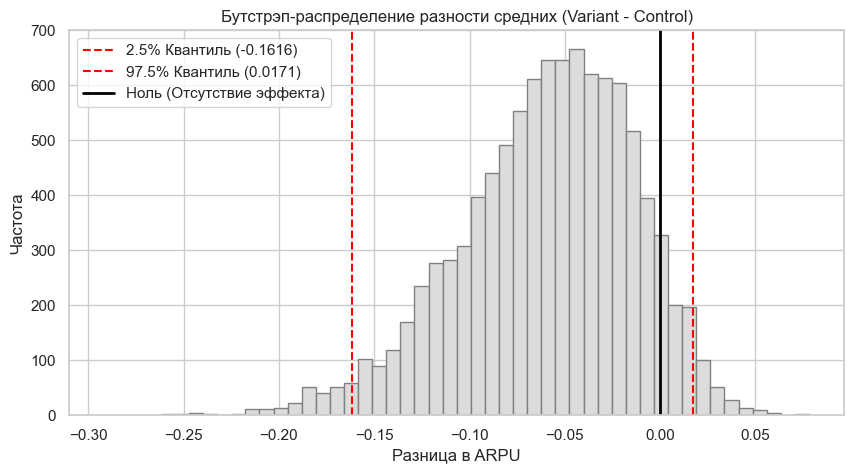

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

control_revenue = df[df["VARIANT_NAME"] == "control"]["REVENUE"].values
variant_revenue = df[df["VARIANT_NAME"] == "variant"]["REVENUE"].values

# Настройки бутстрэпа
n_bootstrap = 10000
bootstrap_diffs = []

# Устанавливаем seed для воспроизводимости результатов
np.random.seed(42)

# Bootstrap
for _ in range(n_bootstrap):
    # Генерируем подвыборки с возвращением (размер равен исходному)
    boot_control = np.random.choice(
        control_revenue, size=len(control_revenue), replace=True
    )
    boot_variant = np.random.choice(
        variant_revenue, size=len(variant_revenue), replace=True
    )

    # Считаем среднее для каждой подвыборки
    mean_control = np.mean(boot_control)
    mean_variant = np.mean(boot_variant)

    # Сохраняем разность средних (эффект от изменений)
    bootstrap_diffs.append(mean_variant - mean_control)

# Превращаем в массив numpy для удобства работы с квантилями
bootstrap_diffs = np.array(bootstrap_diffs)

left_quantile = np.percentile(bootstrap_diffs, 2.5)
right_quantile = np.percentile(bootstrap_diffs, 97.5)

print(f"Эффект (Разница средних Variant - Control): {np.mean(variant_revenue) - np.mean(control_revenue):.4f}")
print(f"95% Доверительный интервал: [{left_quantile:.4f}; {right_quantile:.4f}]")

plt.figure(figsize=(10, 5))
plt.hist(bootstrap_diffs, bins=50, color="gainsboro", edgecolor="gray")
plt.axvline(
    left_quantile,
    color="red",
    linestyle="--",
    label=f"2.5% Квантиль ({left_quantile:.4f})",
)
plt.axvline(
    right_quantile,
    color="red",
    linestyle="--",
    label=f"97.5% Квантиль ({right_quantile:.4f})",
)
plt.axvline(
    0,
    color="black",
    linestyle="-",
    linewidth=2,
    label="Ноль (Отсутствие эффекта)",
)
plt.title("Бутстрэп-распределение разности средних (Variant - Control)")
plt.xlabel("Разница в ARPU")
plt.ylabel("Частота")
plt.legend()
plt.show()

Так как 0 находится в доверительном интервале, нулевую гипотезу отвергнуть нельзя